In [55]:
from pillow_heif import register_heif_opener
register_heif_opener()


In [54]:
pip install torch torchvision pillow openai-clip scikit-learn

In [53]:
import json
with open("faucet_metadata.json","r") as f:
    metadata = json.load(f)


In [36]:
import os
dataset_images = [os.path.join("images", fname) for fname in os.listdir("images") if fname.endswith(".png")]


In [37]:
!ls


'Faucet Identification Task.pdf'   images-20251205T082756Z-3-001.zip
 faucet_metadata.json		   sample_data
 images				   testing_images-20251205T082348Z-3-001.zip


In [38]:
!unzip -o images*.zip

Archive:  images-20251205T082756Z-3-001.zip
  inflating: images/6241757419000_3.png  
  inflating: images/6241287419115_19.png  
  inflating: images/6113961617000_1.png  
  inflating: images/6417441501000_0.png  
  inflating: images/6171308479000_2.png  
  inflating: images/6414508462000_6.png  
  inflating: images/6437550501781_0.png  
  inflating: images/6432342535000_4.png  
  inflating: images/6432452432000_2.png  
  inflating: images/6241286419112_13.png  
  inflating: images/6414345461000_6.png  
  inflating: images/6414508474000_9.png  
  inflating: images/6413341501000_0.png  
  inflating: images/6412842472000_5.png  
  inflating: images/6432459571000_9.png  
  inflating: images/6413749490000_6.png  
  inflating: images/6432452535000_3.png  
  inflating: images/6241286501116_4.png  
  inflating: images/6413749474000_7.png  
  inflating: images/6432447501000_0.png  
  inflating: images/6417744490000_11.png  
  inflating: images/6241657501000_0.png  
  inflating: images/643235253

In [39]:
import clip, torch
from PIL import Image
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


In [40]:
import torchvision.models as models
resnet = models.resnet50(pretrained=True)
# Remove the last layer to get 2048-dim features
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1])).to(device)
resnet.eval()


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [41]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # allow loading large-metadata images

features = {}
for img_path in dataset_images:
    try:
        img = Image.open(img_path).convert("RGB")
        image = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            emb = model.encode_image(image)  # shape [1, 512]
        emb = emb[0].cpu().numpy()
        features[img_path] = emb

    except Exception as e:
        print(f"❌ Skipping {img_path}: {e}")


In [42]:
import numpy as np
vec = emb / np.linalg.norm(emb)
features[img_path] = vec


In [56]:
import os
print(os.listdir('testing_images'))


['IMG_7007.HEIC', 'IMG_7068.HEIC', 'IMG_6975.HEIC', 'IMG_7040.HEIC', 'IMG_7073.HEIC', 'IMG_7046 2.HEIC', 'IMG_7079.HEIC', 'IMG_7049.HEIC', 'IMG_7160.HEIC', 'IMG_7106.HEIC', 'IMG_7074.HEIC', 'IMG_7055.HEIC', 'IMG_7113.HEIC', 'IMG_7152.HEIC', 'IMG_7107.HEIC', 'IMG_6990.HEIC', 'IMG_7037.HEIC', 'IMG_7141.HEIC', 'IMG_7065.HEIC', 'IMG_7166.HEIC', 'IMG_7148.HEIC', 'IMG_7024.HEIC', 'IMG_7033.HEIC', 'IMG_6974.HEIC', 'IMG_7108.HEIC', 'IMG_7057.HEIC', 'IMG_6997.HEIC', 'IMG_6977.HEIC', 'IMG_7051.HEIC', 'IMG_7080.HEIC', 'IMG_7155.HEIC', 'IMG_7125.HEIC', 'IMG_7100.HEIC', 'IMG_7171.HEIC', 'IMG_6986.HEIC', 'IMG_6998.HEIC', 'IMG_7050.HEIC', 'IMG_7026.HEIC', 'IMG_7173.HEIC', 'IMG_7034.HEIC', 'IMG_7165.HEIC', 'IMG_7071.HEIC', 'IMG_6999.HEIC', 'IMG_7123.HEIC', 'IMG_7060.HEIC', 'IMG_7120.HEIC', 'IMG_7101.HEIC', 'IMG_7126.HEIC', 'IMG_7089.HEIC', 'IMG_7085.HEIC', 'IMG_7009.HEIC', 'IMG_7093.HEIC', 'IMG_7008.HEIC', 'IMG_7128.HEIC', 'IMG_7095.HEIC', 'IMG_7066.HEIC', 'IMG_7102.HEIC', 'IMG_7087.HEIC', 'IMG_6972.H

In [44]:
!unzip -o testing_images*.zip


Archive:  testing_images-20251205T082348Z-3-001.zip
  inflating: testing_images/IMG_7174.HEIC  
  inflating: testing_images/IMG_7173.HEIC  
  inflating: testing_images/IMG_7175.HEIC  
  inflating: testing_images/IMG_7169.HEIC  
  inflating: testing_images/IMG_7171.HEIC  
  inflating: testing_images/IMG_7170.HEIC  
  inflating: testing_images/IMG_7167.HEIC  
  inflating: testing_images/IMG_7168.HEIC  
  inflating: testing_images/IMG_7172.HEIC  
  inflating: testing_images/IMG_7166.HEIC  
  inflating: testing_images/IMG_7164.HEIC  
  inflating: testing_images/IMG_7165.HEIC  
  inflating: testing_images/IMG_7161.HEIC  
  inflating: testing_images/IMG_7162.HEIC  
  inflating: testing_images/IMG_7163.HEIC  
  inflating: testing_images/IMG_7160.HEIC  
  inflating: testing_images/IMG_7159.HEIC  
  inflating: testing_images/IMG_7157.HEIC  
  inflating: testing_images/IMG_7154.HEIC  
  inflating: testing_images/IMG_7155.HEIC  
  inflating: testing_images/IMG_7158.HEIC  
  inflating: testing_ima

In [45]:
!pip install pillow-heif


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.4 MB/s eta 0:00:00


In [57]:
query_image = preprocess(
    Image.open("testing_images/IMG_7143.HEIC").convert("RGB")
).unsqueeze(0).to(device)

query_emb = model.encode_image(query_image)[0].detach().cpu().numpy()
query_emb /= np.linalg.norm(query_emb)  # normalize


In [58]:
from sklearn.metrics.pairwise import cosine_similarity
sims = {}
for img_path, emb in features.items():
    # reshape for sklearn
    sim = cosine_similarity(query_emb.reshape(1,-1), emb.reshape(1,-1))[0][0]
    sims[img_path] = sim


In [59]:
top_match = max(sims, key=sims.get)
top_score = sims[top_match]


In [61]:
sorted_matches = sorted(sims.items(), key=lambda x: x[1], reverse=True)
top5 = sorted_matches[:5]  # list of (img_path, score)


In [60]:
print(f"Query image matched to: {top_match} with similarity {top_score:.3f}")


Query image matched to: images/6431745501781_0.png with similarity 0.695


In [62]:
meta = metadata.get(top_match, {})
print("Matched Faucet ID:", meta.get("ArticleNr"))
print("Brand:", meta.get("Brand"))
print("Title:", meta.get("Title"))


Matched Faucet ID: 6431745501781
Brand: Dornbracht
Title: Einlochmischer Dornbracht Imo, ohne Ablaufentil, Auslauf fest, A 165 mm, Höhe Mischdüse 235 mm, , Verchromt, mit Luftsprudler


In [63]:
import json

# Load faucet metadata
with open("faucet_metadata.json", "r") as f:
    metadata = json.load(f)

# Example filter: Only keep images where the brand is 'GROHE'
target_brand = "GROHE"
filtered_images = [
    img_path for img_path in dataset_images
    if metadata.get(os.path.basename(img_path), {}).get("Brand") == target_brand
]

# Optional: if no images matched, fall back to using all images
if not filtered_images:
    print("No matching images found for brand, using full dataset instead.")
    filtered_images = dataset_images


No matching images found for brand, using full dataset instead.


In [64]:
for img_path in filtered_images:
    # run similarity or hashing etc.
    ...


In [65]:
import os
os.rename("testing_images/IMG_7143.HEIC", "testing_images/query1.png")


In [66]:
# 1. Imports and setup
import os, json
import torch, clip
from PIL import Image
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 2. Load model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 3. Load metadata
with open("faucet_metadata.json","r") as f:
    metadata = json.load(f)

# 4. Prepare dataset embeddings
features = {}
for fname in os.listdir("images"):
    if not fname.endswith(".png"):
        continue
    path = os.path.join("images", fname)
    img = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(img)[0].cpu().numpy()
    emb /= np.linalg.norm(emb)  # L2 normalize
    features[path] = emb

# 5. Process each query
query_path = "testing_images/query1.png"
q_img = preprocess(Image.open(query_path).convert("RGB")).unsqueeze(0).to(device)
q_emb = model.encode_image(q_img)[0].detach().cpu().numpy()
q_emb /= np.linalg.norm(q_emb)

# 6. Compute similarities
sims = {path: cosine_similarity(q_emb.reshape(1, -1), emb.reshape(1, -1))[0][0]
        for path, emb in features.items()}
best_match = max(sims, key=sims.get)
score = sims[best_match]

# 7. Output result
print("Query:", query_path)
print("Best match:", best_match, f"(score {score:.3f})")
print("Metadata:", metadata.get(best_match))


Query: testing_images/query1.png
Best match: images/6431745501781_0.png (score 0.695)
Metadata: {'ArticleNr': '6431745501781', 'ArticleNr_masked': '6431 745.501.781', 'MasterArticleNr': '6431745', 'Brand': 'Dornbracht', 'VarDim_Color': 'Verchromt', 'Farbe': ['Chrom'], 'Title': 'Einlochmischer Dornbracht Imo, ohne Ablaufentil, Auslauf fest, A 165 mm, Höhe Mischdüse 235 mm, , Verchromt, mit Luftsprudler', 'Description_long': 'Einlochmischer Dornbracht Imo, ohne Ablaufentil, Auslauf fest, A 165 mm, Höhe Mischdüse 235 mm, Gesamthöhe 278 mm, Bedienung seitlich, für Auflegewaschtische, Schlauchanschlüsse ⅜"', 'Description_short': 'Einlochmischer Dornbracht Imo, ohne Ablaufentil, Auslauf fest, A 165 mm, Höhe Mischdüse 235 mm,', 'ImageURL': 'https://profishop.sanitastroesch.ch/multimedia/Web/PG1/06431745_501_781.png', 'Price': 867, 'EAN': '4099477153827', 'Warengruppe': ['Waschtischarmatur'], 'Produktlinie': ['Imo'], 'Montageart': ['Platte/Armaturenloch'], 'dimensions': {'Breite~~mm': ['120'],

✅ Query: testing_images/query1.png
🏆 Best match: images/6431745501781_0.png (score: 0.695)
📋 Metadata: None


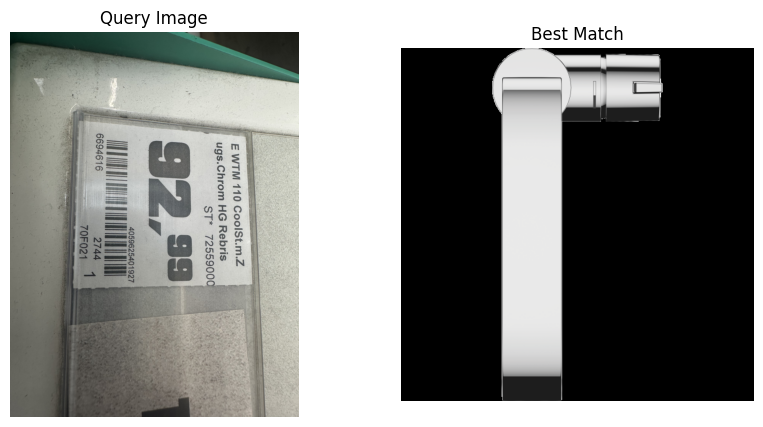

In [67]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Rename a real file to query1.png if needed
if not os.path.exists("testing_images/query1.png"):
    os.rename("testing_images/IMG_7143.HEIC", "testing_images/query1.png")

# Load and preprocess the query image
query_path = "testing_images/query1.png"
q_img = preprocess(Image.open(query_path).convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    q_emb = model.encode_image(q_img)[0].detach().cpu().numpy()
q_emb /= np.linalg.norm(q_emb)

# Compute similarity with dataset embeddings
sims = {
    path: cosine_similarity(q_emb.reshape(1, -1), emb.reshape(1, -1))[0][0]
    for path, emb in features.items()
}
best_match = max(sims, key=sims.get)
score = sims[best_match]

# Print results
print("✅ Query:", query_path)
print("🏆 Best match:", best_match, f"(score: {score:.3f})")
print("📋 Metadata:", metadata.get(os.path.basename(best_match)))

# Show images
query_img = Image.open(query_path).convert("RGB")
matched_img = Image.open(best_match).convert("RGB")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(query_img)
plt.title("Query Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(matched_img)
plt.title("Best Match")
plt.axis("off")
plt.show()
